# VQCFD Results Analysis

Reusable notebook to load and analyze runs saved by the refactored `simulation_runner.py`.

It supports loading by `dir_label` + `label`, reading `manifest` / `values.yaml`, loading arrays (`params`, `costs`, `times`, `variance`) and per-timestep histories (`cost_iter`, `params_iter`).

In [37]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import re
from typing import Any

import numpy as np
import matplotlib.pyplot as plt
import yaml

plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.grid'] = True

In [38]:
REPO_ROOT = Path.cwd()
RESULTS_ROOT = REPO_ROOT / 'results'
RESULTS_ROOT

PosixPath('/Users/joel/Documents/MA/Code/VQCFD/results')

In [39]:
@dataclass
class RunData:
    dir_label: str
    label: str
    full_label: str
    results_dir: Path
    data_dir: Path
    fig_dir: Path
    manifest: dict[str, Any]
    values: dict[str, Any]
    files: dict[str, Path]

    def load_array(self, key: str):
        path = self.files.get(key)
        if path is None or not path.exists():
            return None
        return np.load(path, allow_pickle=True)

    @property
    def costs(self): return self.load_array('costs')
    @property
    def times(self): return self.load_array('times')
    @property
    def params(self): return self.load_array('params')
    @property
    def variance(self): return self.load_array('variance')

In [40]:
def _safe_yaml(path: Path) -> dict[str, Any]:
    if not path.exists():
        return {}
    with path.open('r', encoding='utf-8') as fh:
        return yaml.safe_load(fh) or {}


def _run_paths(dir_label: str, label: str):
    results_dir = RESULTS_ROOT / f'results_{dir_label}'
    data_dir = results_dir / f'data_{label}'
    fig_dir = results_dir / f'figures_{label}'
    full_label = f'{dir_label}_{label}'
    return results_dir, data_dir, fig_dir, full_label


def load_run(dir_label: str, label: str) -> RunData:
    results_dir, data_dir, fig_dir, full_label = _run_paths(dir_label, label)
    if not data_dir.exists():
        raise FileNotFoundError(f'Data directory not found: {data_dir}')
    manifest_path = results_dir / f'manifest_{full_label}.yaml'
    values_yaml = data_dir / f'values_{full_label}.yaml'
    files = {
        'manifest': manifest_path,
        'values_yaml': values_yaml,
        'params': data_dir / f'params_{full_label}.npy',
        'costs': data_dir / f'costs_{full_label}.npy',
        'times': data_dir / f'times_{full_label}.npy',
        'variance': data_dir / f'variance_{full_label}.npy',
        'num_evals': data_dir / f'num_evals_{full_label}.npy',
    }
    return RunData(dir_label, label, full_label, results_dir, data_dir, fig_dir, _safe_yaml(manifest_path), _safe_yaml(values_yaml), files)

In [41]:
def list_runs(results_root: Path = RESULTS_ROOT):
    rows = []
    for results_dir in sorted(results_root.glob('results_*')):
        dir_label = results_dir.name.removeprefix('results_')
        for data_dir in sorted(results_dir.glob('data_*')):
            label = data_dir.name.removeprefix('data_')
            full_label = f'{dir_label}_{label}'
            values = _safe_yaml(data_dir / f'values_{full_label}.yaml')
            manifest = _safe_yaml(results_dir / f'manifest_{full_label}.yaml')
            rows.append({
                'dir_label': dir_label,
                'label': label,
                'full_label': full_label,
                'mode': values.get('mode', manifest.get('mode')),
                'n': values.get('n'),
                'l': values.get('l'),
                'shots': values.get('shots'),
                'has_costs': (data_dir / f'costs_{full_label}.npy').exists(),
                'has_variance': (data_dir / f'variance_{full_label}.npy').exists(),
                'path': str(data_dir),
            })
    return rows


def print_runs(runs=None, limit=200):
    runs = list_runs() if runs is None else runs
    for row in runs[:limit]:
        print(f"{row['full_label']:<12} mode={str(row['mode']):<12} n={str(row['n']):<3} l={str(row['l']):<3} costs={row['has_costs']} variance={row['has_variance']}")
    print(f'count={len(runs)}')

In [72]:
def list_initial_param_presets(
    presets_path: Path | None = None,
    show_variants: bool = True,
    n: int | None = None,
    l: int | None = None,
):
    """Print and return available initial-parameter presets from initial_params_presets.yaml.

    Filters:
    - n: only show presets with this N
    - l: only show presets with this L
    """
    presets_path = presets_path or (REPO_ROOT / 'initial_params_presets.yaml')
    data = _safe_yaml(presets_path)
    if not data:
        print(f'No presets found at: {presets_path}')
        return []

    rows = []
    for n_key in sorted(data, key=lambda x: int(x)):
        n_int = int(n_key)
        if n is not None and n_int != int(n):
            continue

        by_l = data[n_key] or {}
        for l_key in sorted(by_l, key=lambda x: int(x)):
            l_int = int(l_key)
            if l is not None and l_int != int(l):
                continue

            entry = by_l[l_key] or {}
            default_params = entry.get('default') if isinstance(entry, dict) else entry
            default_len = None if default_params is None else len(default_params)
            default_mse = entry.get('default_mse') if isinstance(entry, dict) else None
            variants = []
            if isinstance(entry, dict):
                for vname, ventry in (entry.get('variants') or {}).items():
                    if isinstance(ventry, dict):
                        variants.append({
                            'name': vname,
                            'len': len(ventry.get('params', [])) if isinstance(ventry.get('params'), list) else None,
                            'mse': ventry.get('mse'),
                        })
                    else:
                        variants.append({'name': vname, 'len': len(ventry) if isinstance(ventry, list) else None, 'mse': None})
            rows.append({
                'n': n_int,
                'l': l_int,
                'default_len': default_len,
                'default_mse': default_mse,
                'variants': variants,
            })

    if not rows:
        print(f'No presets found for filters n={n}, l={l}')
        return []

    for r in rows:
        base = f"N={r['n']}, L={r['l']} | default_len={r['default_len']}"
        if r['default_mse'] is not None:
            base += f" | default_mse={r['default_mse']}"
        print(base)
        if show_variants and r['variants']:
            for v in r['variants']:
                extra = f"    variant={v['name']}"
                if v['len'] is not None:
                    extra += f" | len={v['len']}"
                if v['mse'] is not None:
                    extra += f" | mse={v['mse']}"
                print(extra)
    print(f'count={len(rows)} presets')
    return rows

# Examples:
# preset_rows = list_initial_param_presets()
# preset_rows_n4 = list_initial_param_presets(n=4)
# preset_rows_l2 = list_initial_param_presets(l=2)
# preset_rows_n4_l2 = list_initial_param_presets(n=4, l=2)

presets_t = list_initial_param_presets(n = 6,show_variants=False)


N=6, L=1 | default_len=13 | default_mse=0.026308669655778574
N=6, L=2 | default_len=19 | default_mse=0.00034216808447705345
N=6, L=3 | default_len=25 | default_mse=0.00022093751229731567
N=6, L=4 | default_len=31 | default_mse=1.4132765958221204e-06
N=6, L=5 | default_len=37 | default_mse=2.6986324565342634e-06
N=6, L=6 | default_len=43 | default_mse=1.5119335353666355e-06
N=6, L=7 | default_len=49 | default_mse=1.4055003835099423e-07
N=6, L=8 | default_len=55
count=8 presets


In [42]:
runs = list_runs()
print_runs(runs)

N3_L2        mode=noise_free   n=3   l=2   costs=True variance=False
N3_L3        mode=noise_free   n=3   l=3   costs=True variance=False
N4_L2        mode=noise_free   n=4   l=2   costs=True variance=False
N4_L3        mode=noise_free   n=4   l=3   costs=True variance=False
N4_L4        mode=noise_free   n=4   l=4   costs=True variance=False
N5_L4        mode=noise_free   n=5   l=4   costs=True variance=False
var_N3L1     mode=variance     n=3   l=1   costs=False variance=True
var_N3L2     mode=variance     n=3   l=2   costs=False variance=True
var_N4L2     mode=variance     n=4   l=2   costs=False variance=True
count=9


In [43]:
# --- Select a run ---
DIR_LABEL = 'N4'
LABEL = 'L2'
run = load_run(DIR_LABEL, LABEL)
run

RunData(dir_label='N4', label='L2', full_label='N4_L2', results_dir=PosixPath('/Users/joel/Documents/MA/Code/VQCFD/results/results_N4'), data_dir=PosixPath('/Users/joel/Documents/MA/Code/VQCFD/results/results_N4/data_L2'), fig_dir=PosixPath('/Users/joel/Documents/MA/Code/VQCFD/results/results_N4/figures_L2'), manifest={'cobyla_maxiter': 100000, 'cobyla_tol': 1e-05, 'compute_expr_cap': False, 'data_dir': 'results/results_N4/data_L2', 'dir_label': 'N4', 'dt': 0.01, 'expr_bins': 100, 'expr_entcap_samples': 100000, 'fig_dir': 'results/results_N4/figures_L2', 'grad_tol': 0.001, 'init_param_random_center': 2.891592653589793, 'init_param_random_scale': 0.1, 'initial_params': None, 'initial_params_presets_file': 'initial_params_presets.yaml', 'initial_params_variant': None, 'l': 2, 'label': 'L2', 'manifest_path': 'results/results_N4/manifest_N4_L2.yaml', 'max_iter': 100, 'mode': 'noise_free', 'mu': 0.01, 'n': 4, 'n_timesteps': 28, 'n_total': 16, 'optimization_steps': 1000, 'patience': 15, 'pla

In [44]:
print('manifest path:', run.files['manifest'])
print('values yaml path:', run.files['values_yaml'])
print('values keys:', list(run.values.keys()))
run.values

manifest path: /Users/joel/Documents/MA/Code/VQCFD/results/results_N4/manifest_N4_L2.yaml
values yaml path: /Users/joel/Documents/MA/Code/VQCFD/results/results_N4/data_L2/values_N4_L2.yaml
values keys: ['n', 'l', 'shots', 'max_iter', 't_total', 'mu', 'dt', 'plat_tol', 'patience', 'initial_params_source', 'initial_fit_mse', 'shots_used_per_timestep', 'shots_used_total']


{'n': 4,
 'l': 2,
 'shots': 100,
 'max_iter': 100,
 't_total': 0.29,
 'mu': 0.01,
 'dt': 0.01,
 'plat_tol': 0.00015,
 'patience': 15,
 'initial_params_source': 'preset',
 'initial_fit_mse': 1.7556122572331897e-11,
 'shots_used_per_timestep': [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 'shots_used_total': 0}

In [45]:
costs = run.costs
times = run.times
params = run.params
variance = run.variance

print('costs:', None if costs is None else costs.shape)
print('times:', None if times is None else times.shape)
print('params:', None if params is None else params.shape)
print('variance:', None if variance is None else np.shape(variance), variance)

costs: (28,)
times: (28,)
params: (29, 13)
variance: None None


In [46]:
def load_per_timestep_histories(run: RunData, prefix: str):
    pattern = re.compile(rf'{re.escape(prefix)}_{re.escape(run.full_label)}_(\d+)\.npy$')
    entries = []
    for p in run.data_dir.glob(f'{prefix}_{run.full_label}_*.npy'):
        m = pattern.match(p.name)
        if m:
            entries.append((int(m.group(1)), p))
    entries.sort(key=lambda x: x[0])
    return [(i, np.load(p, allow_pickle=True)) for i, p in entries]


cost_histories = load_per_timestep_histories(run, 'cost_iter')
param_histories = load_per_timestep_histories(run, 'params_iter')
print('cost_iter timesteps:', len(cost_histories))
print('params_iter timesteps:', len(param_histories))

cost_iter timesteps: 28
params_iter timesteps: 0


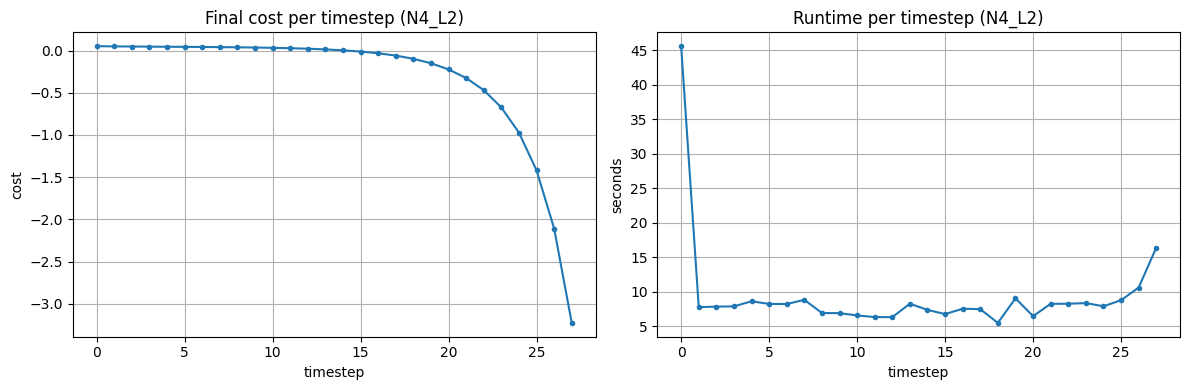

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
if costs is not None:
    axes[0].plot(np.ravel(costs), marker='o', ms=3)
    axes[0].set_title(f'Final cost per timestep ({run.full_label})')
    axes[0].set_xlabel('timestep')
    axes[0].set_ylabel('cost')
else:
    axes[0].text(0.5, 0.5, 'No costs file', ha='center', va='center')
if times is not None:
    axes[1].plot(np.ravel(times), marker='o', ms=3)
    axes[1].set_title(f'Runtime per timestep ({run.full_label})')
    axes[1].set_xlabel('timestep')
    axes[1].set_ylabel('seconds')
else:
    axes[1].text(0.5, 0.5, 'No times file', ha='center', va='center')
plt.tight_layout()

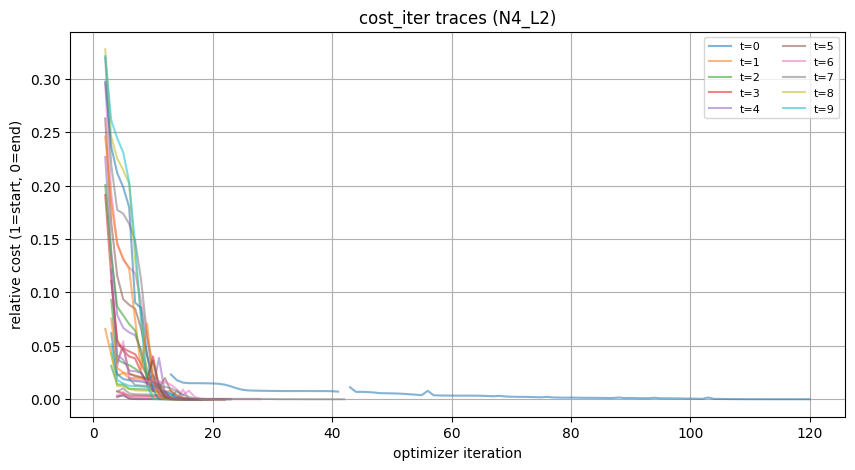

In [50]:
# cost_iter trace plotting options
NORMALIZE_COST_HISTORIES = True      # Normalize each trace using its own initial/final cost
REMOVE_OUTLIERS = True               # Replace outlier points with NaN before plotting
OUTLIER_METHOD = "iqr"              # "iqr" or "percentile"
OUTLIER_FACTOR = 3.0                 # Used for IQR filtering
OUTLIER_PERCENTILES = (1.0, 99.0)    # Used for percentile filtering
SHOW_FIRST_N_LABELS = 10

def _normalize_cost_trace(trace: np.ndarray) -> np.ndarray:
    trace = np.asarray(trace, dtype=float).ravel()
    if trace.size == 0:
        return trace
    c0 = trace[0]
    cf = trace[-1]
    denom = c0 - cf
    if abs(denom) < 1e-15:
        # Degenerate case: almost flat trace
        return np.zeros_like(trace)
    # 1 at initial cost, 0 at final cost
    return (trace - cf) / denom

def _mask_outliers(trace: np.ndarray) -> np.ndarray:
    x = np.asarray(trace, dtype=float).copy()
    finite = np.isfinite(x)
    if finite.sum() < 4:
        return x
    vals = x[finite]

    if OUTLIER_METHOD == "percentile":
        lo, hi = np.percentile(vals, OUTLIER_PERCENTILES)
    else:  # IQR
        q1, q3 = np.percentile(vals, [25, 75])
        iqr = q3 - q1
        if iqr < 1e-15:
            return x
        lo = q1 - OUTLIER_FACTOR * iqr
        hi = q3 + OUTLIER_FACTOR * iqr

    outlier_mask = finite & ((x < lo) | (x > hi))
    x[outlier_mask] = np.nan
    return x

if cost_histories:
    plt.figure(figsize=(10, 5))
    for t_idx, arr in cost_histories:
        y = np.asarray(arr, dtype=float).ravel()
        if NORMALIZE_COST_HISTORIES:
            y = _normalize_cost_trace(y)
        if REMOVE_OUTLIERS:
            y = _mask_outliers(y)
        label = f't={t_idx}' if t_idx < SHOW_FIRST_N_LABELS else None
        plt.plot(y, alpha=0.55, label=label)

    plt.title(f'cost_iter traces ({run.full_label})')
    plt.xlabel('optimizer iteration')
    plt.ylabel('relative cost (1=start, 0=end)' if NORMALIZE_COST_HISTORIES else 'cost')
    if SHOW_FIRST_N_LABELS > 0:
        plt.legend(ncol=2, fontsize=8)
    plt.show()
else:
    print('No cost_iter files found for this run.')


In [ ]:
if params is not None:
    param_idx = 0
    plt.figure(figsize=(9, 4))
    plt.plot(params[:, param_idx], marker='o', ms=3)
    plt.title(f'Parameter[{param_idx}] across timesteps ({run.full_label})')
    plt.xlabel('timestep state index')
    plt.ylabel(f'params[:, {param_idx}]')
    plt.show()

In [ ]:
shots_used_per_timestep = run.values.get('shots_used_per_timestep')
shots_used_total = run.values.get('shots_used_total')
print('shots_used_total:', shots_used_total)
if shots_used_per_timestep is not None:
    plt.figure(figsize=(9, 4))
    plt.plot(shots_used_per_timestep, marker='o', ms=3)
    plt.title(f'Shots used per timestep ({run.full_label})')
    plt.xlabel('timestep')
    plt.ylabel('shots')
    plt.show()

In [ ]:
for k in ['variance', 'variance_tries', 'variance_num_samples', 'variance_runtime_s']:
    if k in run.values:
        print(f'{k}:', run.values[k])
if variance is not None:
    print('variance.npy:', variance)

In [ ]:
RUN_SELECTION = [('N4', 'L2'), ('N4', 'L3')]
loaded = []
for d, l in RUN_SELECTION:
    try:
        loaded.append(load_run(d, l))
    except FileNotFoundError as e:
        print('skip:', e)

for r in loaded:
    c = r.costs
    t = r.times
    print(
        r.full_label,
        '| mode=', r.values.get('mode', r.manifest.get('mode')),
        '| final_cost=', None if c is None or len(c)==0 else float(np.ravel(c)[-1]),
        '| total_time=', None if t is None else float(np.sum(t)),
        '| variance=', r.values.get('variance'),
    )

In [ ]:
plt.figure(figsize=(10, 5))
for r in loaded:
    c = r.costs
    if c is None:
        continue
    plt.plot(np.ravel(c), marker='o', ms=3, label=r.full_label)
plt.title('Final cost per timestep comparison')
plt.xlabel('timestep')
plt.ylabel('cost')
plt.legend()
plt.show()